# Complexity of the Avoided Crossing CASE

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
from src.optimalcontrol_magic_constrain_utils import (
    JaxSchedulerModelMagic,
    JaxTrainerMagic,
)
import pickle

## Initialization of the target Hamiltonian

#### Hyperapameters

In [2]:
import numpy as np
from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian


def mwis_jij_hz(n0, n1, dW, Jzz):
    n = n0 + n1
    G0 = list(range(n0))
    G1 = list(range(n0, n0 + n1))

    jij = np.zeros((n, n))
    for i in G0:
        for j in G1:
            jij[i, j] = Jzz
            jij[j, i] = Jzz

    h0 = n1 * Jzz - 2 * (1 + dW) / n0
    h1 = n0 * Jzz - 2 / n1

    hz = np.zeros(n)
    for i in G0:
        hz[i] = +h0
    for j in G1:
        hz[j] = +h1

    return jij, hz


# ── Example: n0=2, n1=3, matching the paper's 5-qubit instance ───────────────
n0, n1 = 2, 3
dW = 0.01  # small weight imbalance → perturbative crossing
Jzz = 5.33  # edge penalty (closed-system example in paper)

jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)

print("Jij matrix:")
print(np.round(jij, 3))
print("\nhz vector:")
print(np.round(hz, 3))

Jij matrix:
[[0.   0.   5.33 5.33 5.33]
 [0.   0.   5.33 5.33 5.33]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]]

hz vector:
[14.98  14.98   9.993  9.993  9.993]


#### Hamiltonian Initialization

In [4]:
# ── Feed into your src functions ─────────────────────────────────────────────
nqubits = n0 + n1
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse scipy matrix
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse scipy matrix

# ── Verify: ground state energy ──────────────────────────────────────────────
from scipy.sparse.linalg import eigsh

from scipy.sparse.linalg import eigsh
import numpy as np

vals = np.sort(target_hamiltonian.diagonal())
idxs = np.argsort(target_hamiltonian.diagonal())


basis = computational_basis(nqubits)  # shape (2^nqubits, nqubits)

for k in range(4):
    print(f"\nEigenstate {k} in computational basis:")
    # Get the eigenvector (shape (2^nqubits,))
    eigenstate_k = basis[idxs[k]]
    print(eigenstate_k)
    print("Eigenvalue:", vals[k])
    print("\n")


Eigenstate 0 in computational basis:
[0 0 1 1 1]
Eigenvalue: (-31.999999999999996+0j)



Eigenstate 1 in computational basis:
[1 1 0 0 0]
Eigenvalue: (-31.959999999999997+0j)



Eigenstate 2 in computational basis:
[1 1 1 0 0]
Eigenvalue: (-30.62666666666667+0j)



Eigenstate 3 in computational basis:
[1 1 0 1 0]
Eigenvalue: (-30.62666666666667+0j)




#### Analysis of the spectrum of the target hamiltonian

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


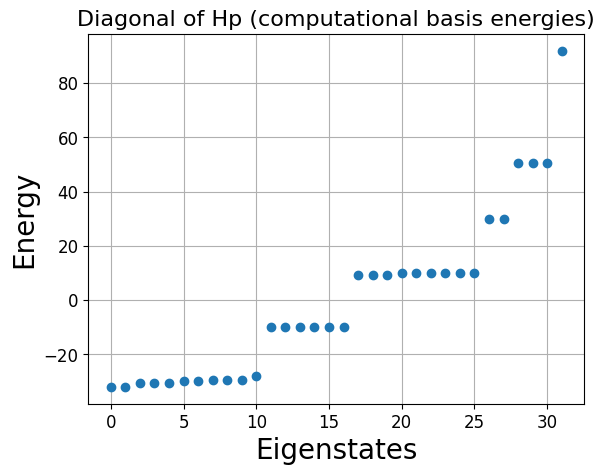

In [5]:
plt.plot(vals, "o")
plt.xlabel("Eigenstates", fontsize=20)
plt.ylabel("Energy", fontsize=20)
plt.title("Diagonal of Hp (computational basis energies)", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid()
plt.show()

#### Time evolution

In [6]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 10
tau = 10
time_steps = int(100 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [7]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
# ── initialization ────────────────────────────────────────────────────────────
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
probabilities = np.zeros((time_steps, nlevels))
psi_history = np.zeros((time_steps, dim), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):

    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + (t / tau) * target_hamiltonian
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(
        hamiltonian_t.astype(complex), which="SA", k=nlevels
    )
    order = np.argsort(spectrum_t)
    spectrum[i] = spectrum_t[order]
    eigenstates_raw = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_raw)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_raw).conj()
    )
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1, 0])
print(spectrum.shape)
print(
    time[np.argmin(spectrum[:, 2] - spectrum[:, 0])],
    np.min(spectrum[:, 2] - spectrum[:, 0]),
)

min_time_gap = time[np.argmin(spectrum[:, 2] - spectrum[:, 0])]

/tmp/ipykernel_2714/3887991952.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i] = (


0.07405613608208206
(1000, 10)
6.536536536536537 1.0965989316945368


Check the results

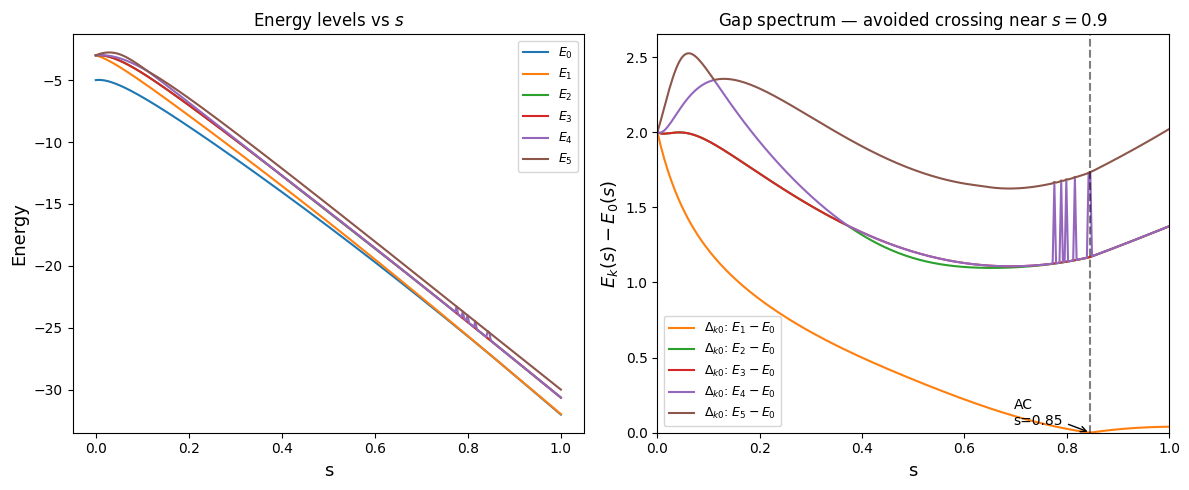

Minimum gap Δ₁₀ = 0.000668 at s = 0.846


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix

# --- Parameters (paper's 5-qubit WGS example) ---
n0, n1 = 2, 3
dW, Jzz = 0.01, 5.33
n = n0 + n1
n_levels = 6  # how many levels to track

# --- Build Hamiltonians ---
jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)
Hp = get_longitudinal_hamiltonian(jij, hz)
Hd = get_driver_hamiltonian(n)

# --- Sweep s ---
s_vals = np.linspace(0, 1, 300)
spectra = np.zeros((len(s_vals), n_levels))

for idx, s in enumerate(s_vals):
    H = (1 - s) * Hd + s * Hp
    vals = eigsh(H, k=n_levels, which="SA", return_eigenvectors=False)
    spectra[idx] = np.sort(vals.real)

E0 = spectra[:, 0]  # ground state energy at each s

# --- Plot 1: Raw energy levels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for k in range(n_levels):
    ax.plot(s_vals, spectra[:, k], label=f"$E_{k}$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title("Energy levels vs $s$")
ax.legend(fontsize=9)

# --- Plot 2: Gaps Δ_k0 = E_k - E_0  (what the paper plots) ---
ax = axes[1]
colors = ["C1", "C2", "C3", "C4", "C5"]
for k in range(1, n_levels):
    gap = spectra[:, k] - E0
    ax.plot(s_vals, gap, color=colors[k - 1], label=f"$\\Delta_{{k0}}$: $E_{k}-E_0$")

ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("$E_k(s) - E_0(s)$", fontsize=13)
ax.set_title("Gap spectrum — avoided crossing near $s=0.9$")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Mark the minimum gap
min_gap = spectra[:, 1] - E0
s_mingap = s_vals[np.argmin(min_gap)]
ax.axvline(
    s_mingap, color="k", linestyle="--", alpha=0.5, label=f"min gap @ s={s_mingap:.2f}"
)
ax.annotate(
    f"AC\ns={s_mingap:.2f}",
    xy=(s_mingap, min_gap.min()),
    xytext=(s_mingap - 0.15, min_gap.min() + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("avoided_crossing.png", dpi=150)
plt.show()

print(f"Minimum gap Δ₁₀ = {min_gap.min():.6f} at s = {s_mingap:.3f}")

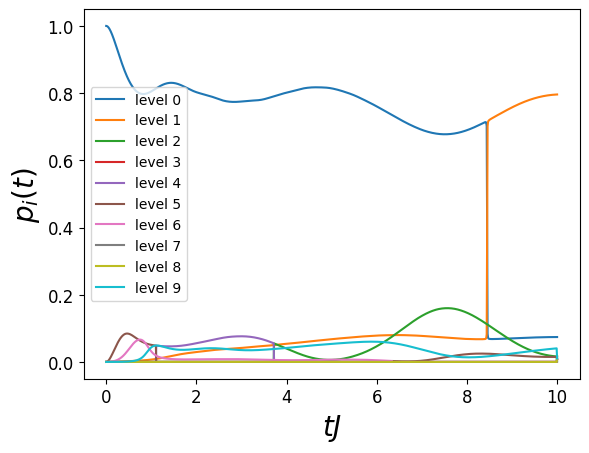

In [11]:
for i in range(nlevels):
    plt.plot(time, probabilities[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [12]:
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

# single state
magic = []
magic_gs_level = []
entanglememt_entropy_history = []
entanglement_entropy_gs_level_history = []
for i in trange(time_steps):
    state = psi_history[i]
    magic.append(sre((state)))
    magic_gs_level.append(sre((eigenstates_history[i, :, 0])))
    entanglememt_entropy_history.append(entanglement_entropy.von_neumann((state)))
    entanglement_entropy_gs_level_history.append(
        entanglement_entropy.von_neumann((eigenstates_history[i, :, 0]))
    )

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=5 (1,024 Paulis)...
Done.
Bipartition: A=2 qubits (4d), B=3 qubits (8d)


100%|██████████| 1000/1000 [00:01<00:00, 872.24it/s]


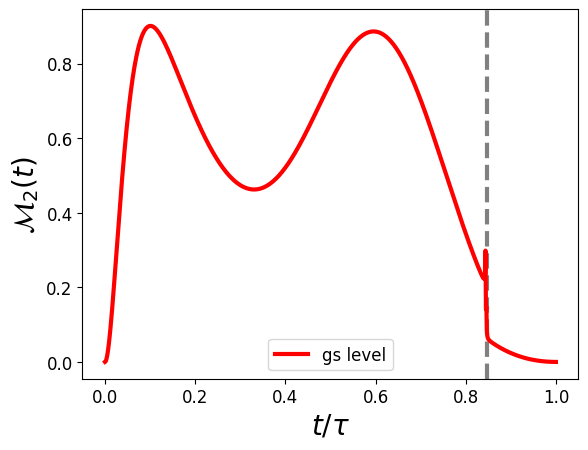

In [14]:
# plt.plot(time, magic, label="evolution", color="blue", linestyle="-", linewidth=3)

plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.plot(
    time / tau,
    magic_gs_level,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

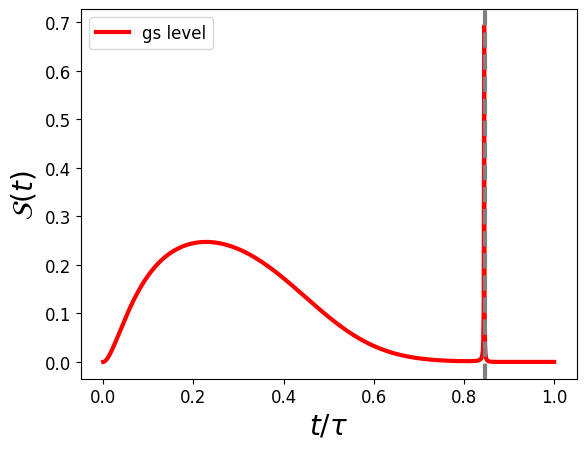

In [15]:
# plt.plot(
#     time / tau,
#     entanglememt_entropy_history,
#     label="evolution",
#     color="blue",
#     linestyle="-",
#     linewidth=3,
# )
plt.plot(
    time / tau,
    entanglement_entropy_gs_level_history,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

In [16]:
from curses.ascii import SP

_, eigenstates_target_hamiltonian = eigsh(
    target_hamiltonian.astype(complex), which="SA", k=4
)
print(sre((eigenstates_target_hamiltonian[:, 0])))

2.220446049250313e-15


## Optimal Control Method

##### Get Hyperparameters

In [20]:
number_parameters = 5
type = "fourier"

#### Jax optimization (optional)

In [21]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode="annealing ansatz",
    random=False,
)

trainer = JaxTrainer(model, maxiter=500, tol=1e-6, ftol=1e-5, gtol=1e-4, verbose=True)
results = trainer.run()

h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]  # already in physical units

JIT compilation done.
-30.963872090142257
-31.765818181374957
-31.798423910386404
-31.833068738986245
-31.85464675232397
-31.876700527280118
-31.916768041318495
-31.922375669772435
-31.93841902110515
-31.9413804765503
-31.943648470810217
-31.945039090205583
-31.945351539992224

Optimization success : True
Final energy         : -31.945352
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


##### Jax with Magic (Optional)

In [ ]:
model = JaxSchedulerModelMagic(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,  # total annealing time
    number_of_parameters=number_parameters,  # Fourier modes per schedule
    nsteps=time_steps,  # time steps
    type=type,  # 'fourier', 'F-CRAB', or 'power law'
    seed=42,
    lambda_magic=100,  # 0.0 = pure energy minimization
    magic_batch_size=4096,  # tune for memory
    random=False,  # random parameter initialization
)

# ── 4. Run optimization ───────────────────────────────────────────────────────
trainer = JaxTrainerMagic(
    model=model,
    maxiter=300,
    tol=1e-6,
    ftol=1e-9,
    gtol=1e-6,
    verbose=True,
)

results = trainer.run()

Building Pauli tables for n=6 (4096 Paulis, sector dim=32, batch=4096)...
Done.


AttributeError: 'JaxSchedulerModelMagic' object has no attribute '_pw_basis'

In [80]:
print(tau, number_parameters, time_steps, type)
print(psi_init.shape, psi_init.dtype)
print(
    target_hamiltonian_s.shape,
)
print(
    driver_hamiltonian_s.shape,
)

0.5 5 50 cumulative
(32,) complex128
(32, 32)
(32, 32)


#### Check the results

(-1.7036845761640171-4.70079342929902j)


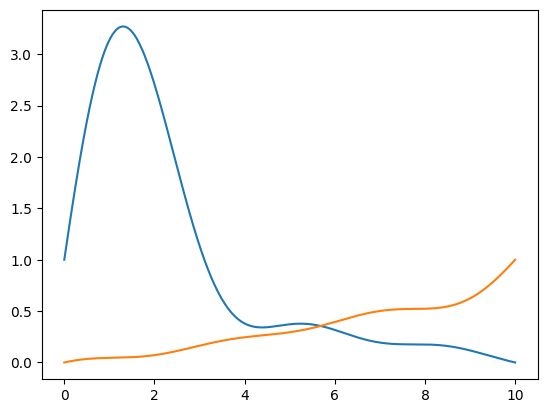

(-31.94535153999258+1.7763568394002505e-15j)


In [22]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian.astype(complex), which="SA", k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0] * driver_hamiltonian.dot(psi_init)))

plt.plot(time, h_driver)
plt.plot(time, h_target)
plt.show()


# initialization
psi = psi_init.copy()
psi_history_optimalcontrol = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i, t in enumerate(time):

    hamiltonian_t = h_driver[i] * driver_hamiltonian + target_hamiltonian * h_target[i]
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    psi_history_optimalcontrol[i] = psi
    # for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian.dot(psi)))

Warm Starting

In [32]:
import numpy as np
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer


def run_fcrab_warm_start(
    psi_init,
    target_hamiltonian_s,
    driver_hamiltonian_s,
    tau,
    time_steps,
    dim_schedule=[2, 4, 8, 16],  # N_c levels to iterate through
    nr=5,  # random restarts per level
    maxiter=2000,
    ftol=1e-9,
    gtol=1e-9,
    verbose=True,
):
    best_params = None  # layout: [a_drv(dim), a_tgt(dim)]
    best_omegas = None  # shape (dim,)
    best_energy = np.inf
    best_psi = None
    best_h_driver = None
    best_h_target = None

    for level_idx, dim in enumerate(dim_schedule):
        dim_prev = dim_schedule[level_idx - 1] if level_idx > 0 else 0
        delta = dim - dim_prev

        if verbose:
            print(f"\n{'='*50}")
            print(f"  N_c = {dim}  (adding {delta} new modes, {nr} restarts)")
            print(f"{'='*50}")

        level_best_energy = np.inf
        level_best_params = None
        level_best_omegas = None
        level_best_psi = None
        level_best_h_driver = None
        level_best_h_target = None

        for restart in range(nr):
            # ── build frequency array ─────────────────────────────────────────
            # old frequencies stay fixed, only new ones are randomised
            rng = np.random.default_rng()  # fresh seed each restart

            new_omegas = (
                np.pi
                * np.arange(dim_prev + 1, dim + 1)
                * (1 + rng.uniform(-0.5, 0.5, delta))
                / tau
            )

            if best_omegas is not None:
                full_omegas = np.concatenate([best_omegas, new_omegas])
            else:
                full_omegas = new_omegas  # first level: all new

            # ── build warm-start parameter vector ─────────────────────────────
            # layout: [a_drv(dim), a_tgt(dim)]
            # old coefficients carried over, new ones zeroed
            init_params = np.zeros(2 * dim)
            if best_params is not None:
                init_params[:dim_prev] = best_params[:dim_prev]  # a_drv old
                init_params[dim : dim + dim_prev] = best_params[dim_prev:]  # a_tgt old

            # ── construct model ───────────────────────────────────────────────
            model = SparseGRAPEModel(
                initial_state=psi_init,
                target_hamiltonian=target_hamiltonian_s,
                initial_hamiltonian=driver_hamiltonian_s,
                reference_hamiltonian=target_hamiltonian_s,
                tf=tau,
                number_of_parameters=dim,
                nsteps=time_steps,
                type="F-CRAB",
                seed=42,
                mode="annealing ansatz",
                random=False,
            )

            # override omegas and recompute sin basis — no JIT recompilation needed
            model.omegas = full_omegas
            model._sin_basis = np.sin(np.outer(full_omegas, model.time))

            # inject warm-start parameters
            model.parameters = init_params.copy()

            # ── optimize ──────────────────────────────────────────────────────
            trainer = SparseGRAPETrainer(
                model,
                maxiter=maxiter,
                ftol=ftol,
                gtol=gtol,
                verbose=verbose,
            )
            results = trainer.run()

            if verbose:
                print(f"  restart {restart+1}/{nr}  E = {results['energy']:.6f}")

            if results["energy"] < level_best_energy:
                level_best_energy = results["energy"]
                level_best_params = results["parameters"].copy()
                level_best_omegas = full_omegas.copy()
                level_best_psi = results["psi"].copy()
                level_best_h_driver = results["h_driver"].copy()
                level_best_h_target = results["h_target"].copy()

        # ── keep best across levels ───────────────────────────────────────────
        if level_best_energy < best_energy:
            best_energy = level_best_energy
            best_params = level_best_params
            best_omegas = level_best_omegas
            best_psi = level_best_psi
            best_h_driver = level_best_h_driver
            best_h_target = level_best_h_target

        if verbose:
            print(f"\n  → best energy at N_c={dim}: {best_energy:.6f}")

    return {
        "h_driver": best_h_driver,
        "h_target": best_h_target,
        "energy": best_energy,
        "psi": best_psi,
        "parameters": best_params,
        "omegas": best_omegas,
    }


# ── usage ─────────────────────────────────────────────────────────────────────
results = run_fcrab_warm_start(
    psi_init=psi_init,
    target_hamiltonian_s=target_hamiltonian,
    driver_hamiltonian_s=driver_hamiltonian,
    tau=tau,
    time_steps=time_steps,
    dim_schedule=[2, 4, 8, 16, 32],
    nr=5,
    maxiter=500,
    ftol=1e-9,
    gtol=1e-9,
    verbose=True,
)

h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]


  N_c = 2  (adding 2 new modes, 5 restarts)
  Initial energy    : -30.805246
  Gradient norm     : 3.690102e+00
  FD  grad[0]       : -9.834329e-01
  GRAPE grad[0]     : -9.919913e-01
  Relative error    : 8.703e-03
-31.328413543367656
-31.546380443236522
-31.600698883705526
-31.61585118211776
-31.641215570567898
-31.649692126792424
-31.6540840259363
-31.654881082383145
-31.656495569914895
-31.656742160328264
-31.656886368677156
-31.656923027338635
-31.65718877593381
-31.65722461117584
-31.657240795693827
-31.657243043200847
-31.65724318633091
-31.657243186331012

Optimization success : True
Final energy         : -31.657243
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  restart 1/5  E = -31.657243
  Initial energy    : -30.805246
  Gradient norm     : 4.929631e+00
  FD  grad[0]       : -9.693684e-01
  GRAPE grad[0]     : -9.778011e-01
  Relative error    : 8.699e-03
-31.05007167411543
-31.306227839703183
-31.370384149476106
-31.45236495144589
-31.541028

KeyboardInterrupt: 

In [34]:
h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]

# initialization
energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_optimalcontrol[i]
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + target_hamiltonian * t / tau
    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = spectrum_t
    # overlap
    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )
    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_optimalcontrol[-1, 0])

/tmp/ipykernel_2714/1319415919.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i] = (
/tmp/ipykernel_2714/1319415919.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))


10.0
(-31.94535153999258+1.7763568394002505e-15j)
0.24896861183936259


In [35]:
print(spectrum_optimalcontrol[-1])

[-32.         -31.96       -30.62666667 -30.62666667 -30.62666667
 -29.98       -29.98       -29.29333333 -29.29333333 -29.29333333]


In [36]:
h_driver, h_target = model.get_driving()
print(f"h_driver[0]  = {h_driver[0]:.6f}")  # should be 1
print(f"h_driver[-1] = {h_driver[-1]:.6f}")  # should be 0
print(f"h_target[0]  = {h_target[0]:.6f}")  # should be 0
print(f"h_target[-1] = {h_target[-1]:.6f}")  # should be 1
print(f"type: {model.type}")
print(f"parameters[:4]: {model.parameters[:4]}")

h_driver[0]  = 1.000000
h_driver[-1] = 0.000000
h_target[0]  = 0.000000
h_target[-1] = 1.000000
type: fourier
parameters[:4]: [0.31347347 0.91661114 0.9964603  0.65041036]


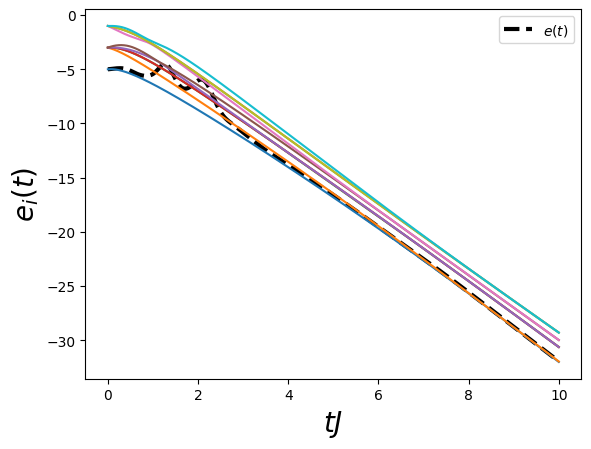

In [37]:
plt.plot(
    time, energy_optimal, color="black", linestyle="--", linewidth=3, label=r"$e(t)$"
)
for i in range(spectrum_optimalcontrol.shape[1]):

    plt.plot(time, spectrum_optimalcontrol[:, i])
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$e_i(t)$", fontsize=20)
plt.legend()
plt.show()

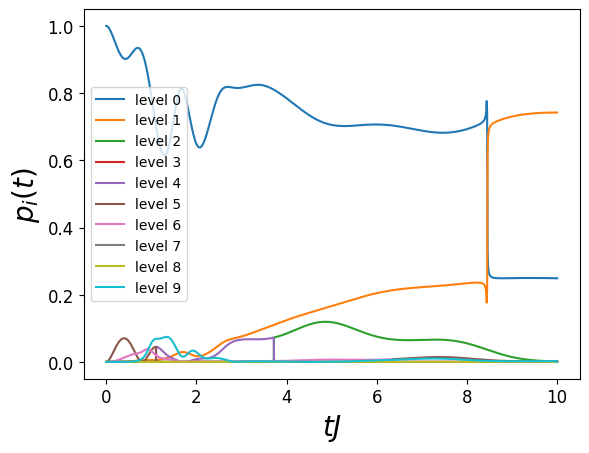

In [38]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimalcontrol[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [29]:
from tqdm import trange

# single state
magic_optimal_control = []
entanglememt_entropy_history_optimal_control = []
for i in trange(time_steps):
    state = psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre((state)))
    entanglememt_entropy_history_optimal_control.append(
        entanglement_entropy.von_neumann((state))
    )

100%|██████████| 1000/1000 [00:00<00:00, 2171.07it/s]


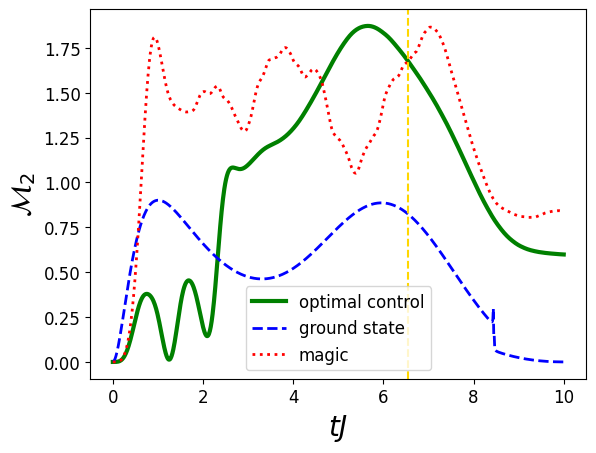

In [30]:
plt.plot(
    time,
    magic_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    magic_gs_level,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(time, magic, label="magic", color="red", linestyle=":", linewidth=2)
plt.axvline(min_time_gap, linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

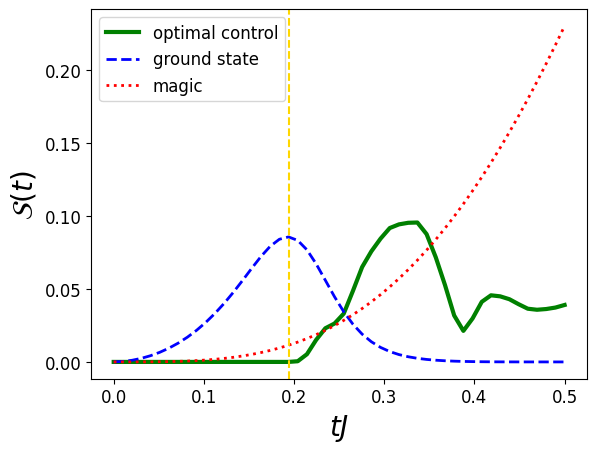

In [89]:
plt.plot(
    time,
    entanglememt_entropy_history_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    entanglement_entropy_gs_level_history,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    time,
    entanglememt_entropy_history,
    label="magic",
    color="red",
    linestyle=":",
    linewidth=2,
)
plt.axvline(min_time_gap, linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

##### Energy Path and NON-STABILIZERNESS through the optimization

[-4.555235846916357, -4.63804632600796, -4.790542942495088, -4.822097512281556, -4.890055320553204, -5.043118982135683, -5.14553026587476, -5.231464975296423, -5.27184137596504, -5.3440379384691115, -5.355219423821952, -5.371492823764503, -5.444648584503674, -5.4617608503468285, -5.503004032579454, -5.535071068378956, -5.624124896832921, -5.745109963994405, -5.809438362312386, -5.820394444602879, -5.828018899366175, -5.829709527741825, -5.830197622239027, -5.831179177845581, -5.832457043168145, -5.836874342614011, -5.843874829347943, -5.854500409530582, -5.881946950590513, -5.894558712673571, -5.918193856692222, -5.949599269427526, -5.977646728535319, -5.980639691545538, -5.985631332718554, -5.985988367491727, -5.987040832330658, -5.991060564248579, -5.992842213835731, -5.994936468198048, -5.995739255924616, -5.996131284873144, -5.99679082235116, -5.99706691381117, -5.997464043783776, -5.997581286439991, -5.997706108243747, -5.997819079107748, -5.998221248937404, -5.998714532161975, -5

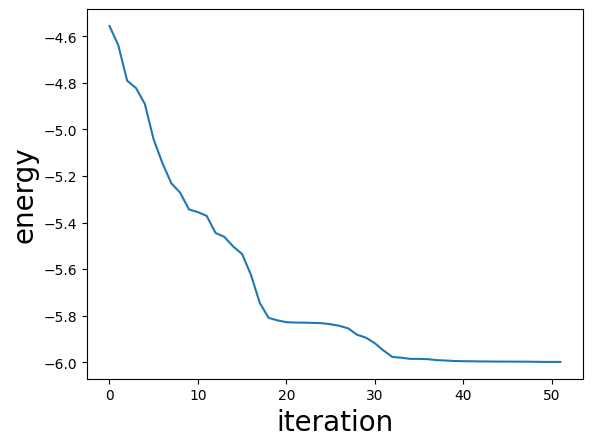

52
(100,)


In [24]:
print(model.history)
plt.plot(np.arange(len(model.history)), model.history)
plt.xlabel("iteration", fontsize=20)
plt.ylabel("energy", fontsize=20)
# plt.yscale('log')
plt.show()
print(len(model.history))


print(model.history_drivings[0][0].shape)

In [25]:
total_magic = []
total_entanglement = []
delta_t = model.tf / model.nsteps
print(len(model.history_drivings[0]))
for i in trange(0, len(model.history_drivings), 1):

    h_driver, h_target = model.history_drivings[i]

    # initialization
    psi = psi_init.copy()
    psi_history_optimalcontrol = np.zeros(
        (time_steps, psi_init.shape[0]), dtype=complex
    )
    magic = []
    entanglement = []
    for i, t in enumerate(time):
        hamiltonian_t = (
            h_driver[i] * driver_hamiltonian_s + target_hamiltonian_s * h_target[i]
        )
        psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
        psi_history_optimalcontrol[i] = psi
        magic.append(sre(PS.lift(psi)))
        entanglement.append(entanglement_entropy.von_neumann(PS.lift(psi)))
    total_magic.append(delta_t * np.sum(magic))
    total_entanglement.append(delta_t * np.sum(entanglement))

2


100%|██████████| 52/52 [00:11<00:00,  4.43it/s]


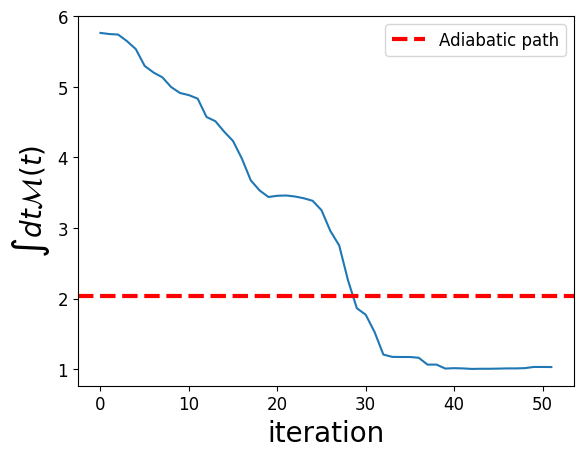

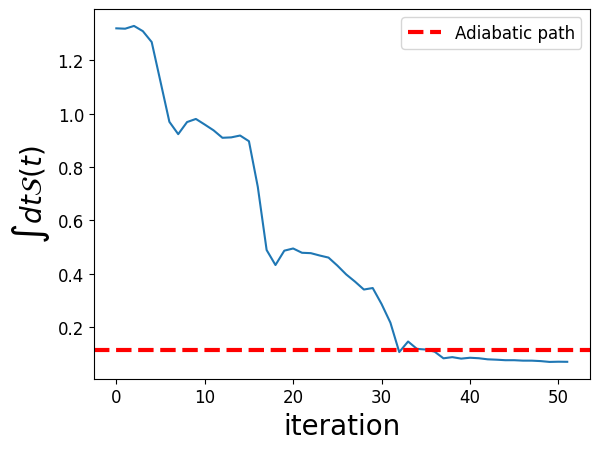

In [26]:
plt.plot(np.arange(len(total_magic)), total_magic)
plt.axhline(
    delta_t * np.sum(magic_gs_level),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\int dt  \mathcal{M}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


plt.plot(np.arange(len(total_entanglement)), total_entanglement)
plt.axhline(
    delta_t * np.sum(entanglement_entropy_gs_level_history),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\int dt  \mathcal{S}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


np.savez(
    f"data/history_optimal_control_{tau:.2f}.npz",
    total_magic=np.asarray(total_magic),
    total_entanglement=np.asarray(total_entanglement),
    energy=np.asarray(model.history),
)

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [39]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term = get_counteradiabatic_term(
    driver_hamiltonian=driver_hamiltonian, target_hamiltonian=target_hamiltonian
)
counteradiabatic_term_s = PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 192 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	4j
  (0, 2)	4j
  (0, 4)	4j
  (0, 8)	4j
  (0, 16)	4j
  (0, 32)	4j
  (1, 0)	(-0-4j)
  (1, 5)	4j
  (1, 9)	4j
  (1, 17)	4j
  (2, 0)	(-0-4j)
  (2, 10)	4j
  (2, 18)	4j
  (2, 34)	4j
  (3, 11)	4j
  (3, 19)	4j
  (4, 0)	(-0-4j)
  (4, 5)	4j
  (4, 20)	4j
  (4, 36)	4j
  (5, 1)	(-0-4j)
  (5, 4)	(-0-4j)
  (5, 7)	(-0-4j)
  (5, 21)	4j
  (6, 22)	4j
  :	:
  (57, 41)	4j
  (58, 42)	4j
  (58, 56)	(-0-4j)
  (58, 59)	(-0-4j)
  (58, 62)	(-0-4j)
  (59, 27)	4j
  (59, 43)	4j
  (59, 58)	4j
  (59, 63)	(-0-4j)
  (60, 44)	4j
  (60, 52)	4j
  (61, 29)	4j
  (61, 45)	4j
  (61, 53)	4j
  (61, 63)	(-0-4j)
  (62, 46)	4j
  (62, 54)	4j
  (62, 58)	4j
  (62, 63)	(-0-4j)
  (63, 31)	4j
  (63, 47)	4j
  (63, 55)	4j
  (63, 59)	4j
  (63, 61)	4j
  (63, 62)	4j


Compute the optimal driving of the adiabatic gauge potential from calculations

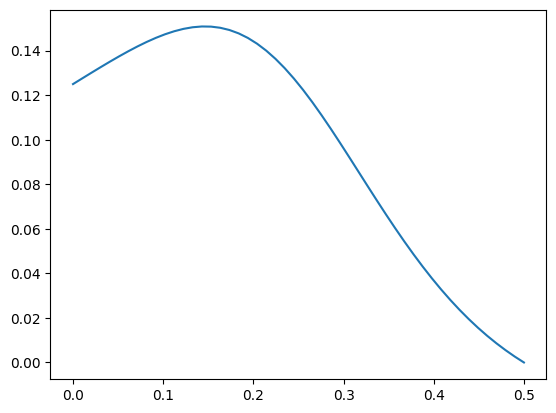

In [40]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2 = np.sum(J**2)  # ||J||^2
    J2_row = np.sum(J**2, axis=1)  # (n,): sum_B J_AB^2
    J4_sum = np.sum(J2_row**2)  # sum_A (sum_B J_AB^2)^2

    numerator = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam) ** 2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator


# schedule of alpha_0 along the annealing
alpha = -1 * np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time, alpha)
plt.show()

In [41]:
from scipy.sparse.linalg import eigsh, expm_multiply
from src.annealing_utils import compute_exact_AGP

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init = PS.project(psi_init)

# initialization

psi = psi_init.copy()
psi_history_counteradiabatic = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic = np.zeros((time_steps, nlevels))
energy_counteradiabatic = np.zeros(time_steps)
for i, t in enumerate(time):
    exact_AGP = compute_exact_AGP(
        driver_hamiltonian=driver_hamiltonian_s,
        target_hamiltonian=target_hamiltonian_s,
        lam=t / tau,
        n_eigs=2,
    )
    hamiltonian_t = (
        (1 - t / tau) * driver_hamiltonian_s
        + target_hamiltonian_s * t / tau
        + (1 / tau) * exact_AGP
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_counteradiabatic[i] = spectrum_t
    energy_counteradiabatic[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i] = psi

/tmp/ipykernel_2880/784023840.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i] = psi.conj().dot(hamiltonian_t.dot(psi))


In [42]:
# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian = np.zeros(time_steps)
probabilities_counteradiabatic = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_counteradiabatic[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * driver_hamiltonian_s + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )

    energy_counteradiabatic_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1, 0])

0.5
(-2.5510140722121797+0j)
-2.5510140722121797
0.38111463695270953


/tmp/ipykernel_2880/614686986.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i] = (
/tmp/ipykernel_2880/614686986.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i] = psi.conj().dot(


##### Results of the unbiased counteradiabatic term

0
-6.000000000000003
-2.5510140722121797
1
-2.0
-2.5510140722121797
2
-2.0
-2.5510140722121797
3
-2.0
-2.5510140722121797
4
-2.0
-2.5510140722121797
5
-2.0
-2.5510140722121797
6
-1.9999999999999998
-2.5510140722121797
7
-1.9999999999999998
-2.5510140722121797
8
-1.9999999999999996
-2.5510140722121797
9
-1.9999999999999996
-2.5510140722121797


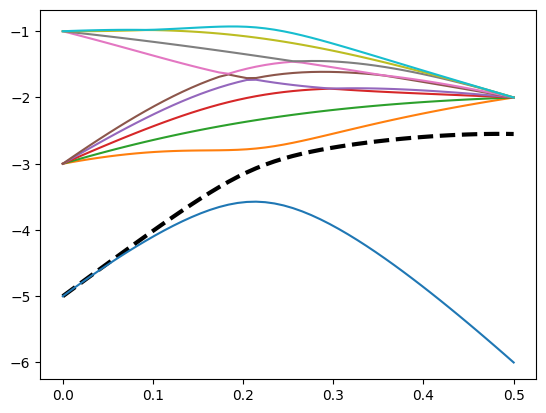

0
-6.009373812628143
1
-2.0000000000000004
2
-2.0000000000000004
3
-2.0000000000000004
4
-2.0
5
-2.0
6
-2.0
7
-2.0
8
-1.9999999999999998
9
-1.9999999999999998


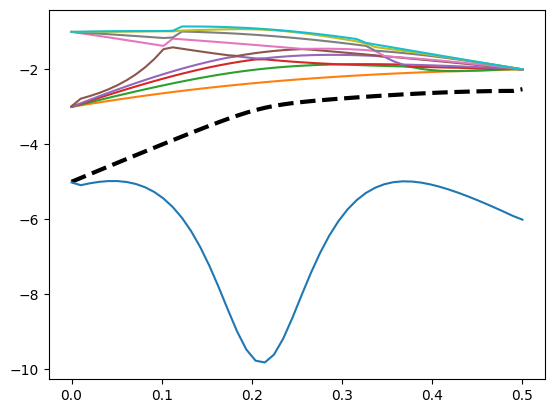

In [43]:
plt.plot(
    time,
    energy_counteradiabatic_linear_hamiltonian,
    color="black",
    linestyle="--",
    linewidth=3,
)
for i in range(spectrum_counteradiabatic.shape[1]):
    print(i)
    print(spectrum[-1, i])
    print(energy_counteradiabatic_linear_hamiltonian[-1])
    plt.plot(time, spectrum[:, i])

plt.show()

plt.plot(time, energy_counteradiabatic, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

    print(i)
    print(spectrum_counteradiabatic[-1, i])
    plt.plot(time, spectrum_counteradiabatic[:, i])

plt.show()

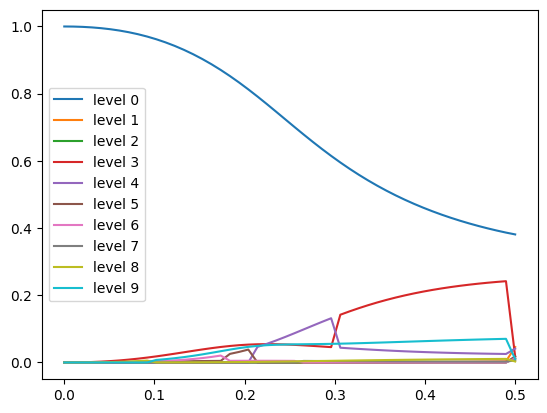

In [44]:
for i in range(nlevels):
    plt.plot(time, probabilities_counteradiabatic[:, i], label=f"level {i}")

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [45]:
# single state
magic_counteradiabatic = []

for i in trange(time_steps):
    state = psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))

100%|██████████| 50/50 [00:00<00:00, 868.12it/s]


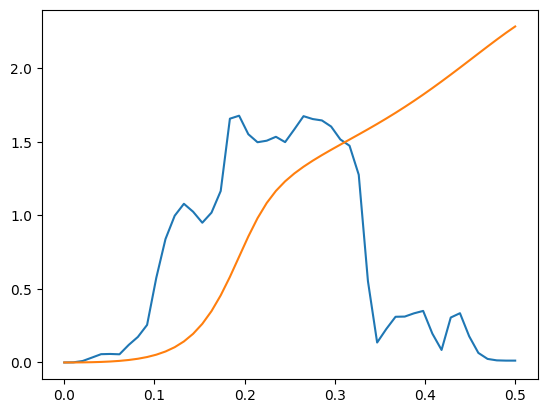

In [46]:
plt.plot(time, magic)
# plt.plot(time,magic_optimal_control)
plt.plot(time, magic_counteradiabatic)
plt.show()

## Non-stoquastic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [55]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

js = np.random.choice([-1, 1], size=(nqubits, nqubits))

nonstoquastic_driving = 0.0
for i in range(nqubits):
    # nonstoquastic_driving+=SpinOperator(index=[('x',i)],coupling=[(-1)**(i)],size=nqubits).qutip_op.data_as('csr_matrix')
    for j in range(i + 1, nqubits):
        nonstoquastic_driving += SpinOperator(
            index=[("x", i, "x", j)], coupling=[js[i, j]], size=nqubits
        ).qutip_op.data_as("csr_matrix")
        # nonstoquastic_driving+=SpinOperator(index=[('y',i,'y',j)],coupling=[(0.5)],size=nqubits).qutip_op.data_as('csr_matrix')

nonstoquastic_driving_s = PS.project(nonstoquastic_driving)

In [57]:
from scipy.sparse.linalg import eigsh, expm_multiply

# combined driver: H_D + beta * H_NS
beta = 1
total_driver_ns = driver_hamiltonian_s


print(total_driver_ns)
_, eigvecs = eigsh(total_driver_ns.astype(complex), which="SA", k=2)
psi_init = eigvecs[:, 0].astype(complex)

# psi_init       = np.ones(total_driver_ns.shape[0], dtype=complex) / np.sqrt(total_driver_ns.shape[0])
e_check = (psi_init.conj() @ total_driver_ns @ psi_init).real
print(f"GS energy check: {e_check:.6f}")  # should match evals[0]

# initialization

psi = psi_init
psi_history_catalyst = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst = np.zeros((time_steps, nlevels))
energy_catalyst = np.zeros(time_steps)
for i, t in enumerate(time):
    psi_history_catalyst[i] = psi
    hamiltonian_t = (
        (1 - t / tau) * total_driver_ns
        + target_hamiltonian_s * t / tau
        + (1 - t / tau) * (t / tau) * nonstoquastic_driving_s
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_catalyst[i] = spectrum_t
    energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 160 stored elements and shape (32, 32)>
  Coords	Values
  (0, 1)	(-1+0j)
  (0, 2)	(-1+0j)
  (0, 4)	(-1+0j)
  (0, 8)	(-1+0j)
  (0, 16)	(-1+0j)
  (1, 0)	(-1+0j)
  (1, 3)	(-1+0j)
  (1, 5)	(-1+0j)
  (1, 9)	(-1+0j)
  (1, 17)	(-1+0j)
  (2, 0)	(-1+0j)
  (2, 3)	(-1+0j)
  (2, 6)	(-1+0j)
  (2, 10)	(-1+0j)
  (2, 18)	(-1+0j)
  (3, 1)	(-1+0j)
  (3, 2)	(-1+0j)
  (3, 7)	(-1+0j)
  (3, 11)	(-1+0j)
  (3, 19)	(-1+0j)
  (4, 0)	(-1+0j)
  (4, 5)	(-1+0j)
  (4, 6)	(-1+0j)
  (4, 12)	(-1+0j)
  (4, 20)	(-1+0j)
  :	:
  (27, 11)	(-1+0j)
  (27, 19)	(-1+0j)
  (27, 25)	(-1+0j)
  (27, 26)	(-1+0j)
  (27, 31)	(-1+0j)
  (28, 12)	(-1+0j)
  (28, 20)	(-1+0j)
  (28, 24)	(-1+0j)
  (28, 29)	(-1+0j)
  (28, 30)	(-1+0j)
  (29, 13)	(-1+0j)
  (29, 21)	(-1+0j)
  (29, 25)	(-1+0j)
  (29, 28)	(-1+0j)
  (29, 31)	(-1+0j)
  (30, 14)	(-1+0j)
  (30, 22)	(-1+0j)
  (30, 26)	(-1+0j)
  (30, 28)	(-1+0j)
  (30, 31)	(-1+0j)
  (31, 15)	(-1+0j)
  (31, 23)	(-1+0j)
  (31, 27)	(-1+0j)
  (

/tmp/ipykernel_2880/3358782213.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))


In [58]:
# initialize the state


# initialization
energy_catalyst_linear_hamiltonian = np.zeros(time_steps)
probabilities_nonstoquastic = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_catalyst[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * total_driver_ns + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_nonstoquastic[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )

    energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_nonstoquastic[-1, 0])

0.5
(-0.4594679562259469+0j)
0.04765695725410843


/tmp/ipykernel_2880/1015930268.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_nonstoquastic[i] = (
/tmp/ipykernel_2880/1015930268.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(


##### Results of the unbiased catalyst

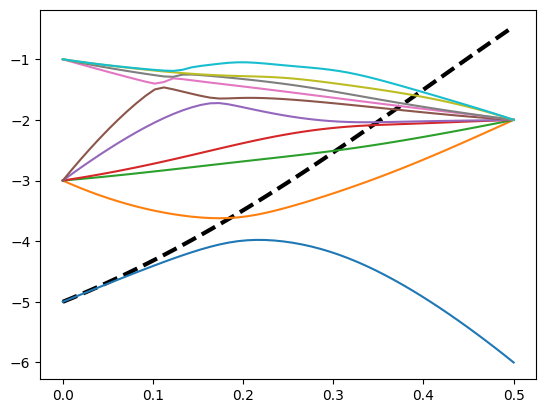

In [59]:
plt.plot(time, energy_catalyst, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_catalyst.shape[1]):

    plt.plot(time, spectrum_catalyst[:, i])

plt.show()

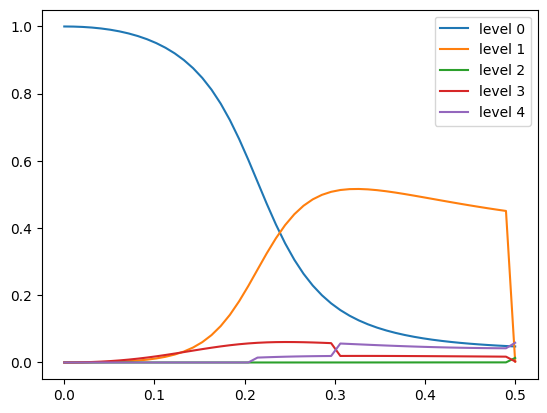

In [60]:
for i in range(nlevels // 2):
    plt.plot(time, probabilities_nonstoquastic[:, i], label=f"level {i}")

plt.legend()
plt.show()

In [ ]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic_nonstoquastic = []
for i in trange(time_steps):
    state = psi_history_catalyst[i]
    magic_nonstoquastic.append(sre(PS.lift(state)))

Building Pauli tables for n=6 (4096 Paulis)...
Done.


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 399.41it/s]


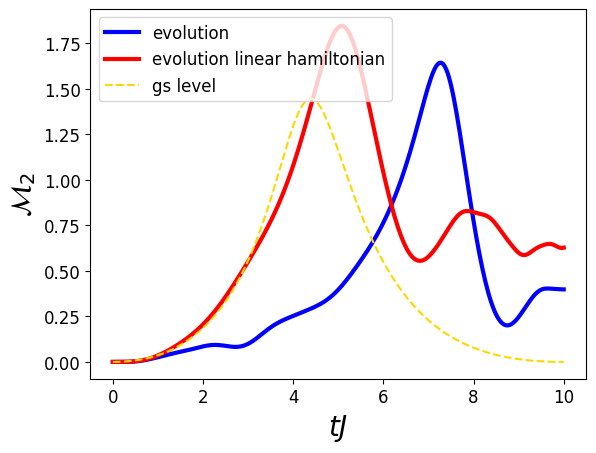

In [ ]:
plt.plot(
    time,
    magic_nonstoquastic,
    label="evolution",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    magic,
    label="evolution linear hamiltonian",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.plot(time, magic_gs_level, label="gs level", linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

## Quench Limit

In [ ]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 10
tau = 10
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [ ]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
_, eigvecs = eigsh(driver_hamiltonian_s, which="SA", k=2)
psi_init = eigvecs[:, 0].astype(complex)

# ── initialization ────────────────────────────────────────────────────────────
tau_q = 0.1 * tau
psi_history_quench = np.zeros((time_steps, dim // 2), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    psi_history_quench[i] = psi
    hamiltonian_t = (t / tau) * target_hamiltonian_s + np.max(
        (1 - t / tau_q), 0
    ) * driver_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

In [ ]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)
# single state
magic_quench = []
entanglement_entropy_history_quench = []
for i in trange(time_steps):
    state = psi_history_quench[i]
    magic_quench.append(sre(PS.lift(state)))
    entanglement_entropy_history_quench.append(
        entanglement_entropy.von_neumann(PS.lift(state))
    )

Building Pauli tables for n=8 (65536 Paulis)...
Done.
Bipartition: A=4 qubits (16d), B=4 qubits (16d)


100%|██████████| 100/100 [00:29<00:00,  3.35it/s]


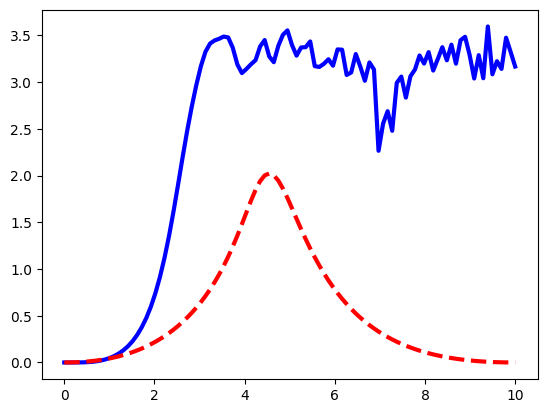

In [ ]:
plt.plot(time, magic_quench, label="quench", color="blue", linestyle="-", linewidth=3)
plt.plot(
    time, magic_gs_level, label="gs level", color="red", linestyle="--", linewidth=3
)

plt.show()

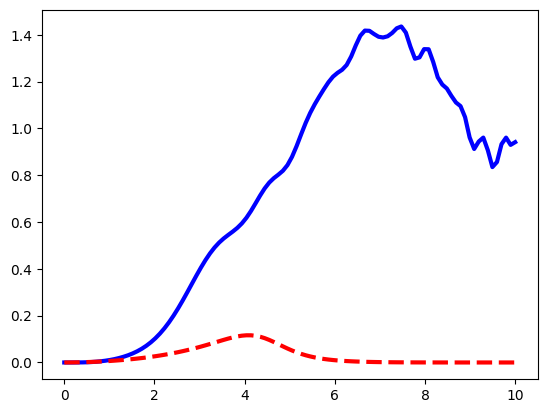

In [ ]:
plt.plot(
    time,
    entanglement_entropy_history_quench,
    label="quench",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    entanglement_entropy_gs_level_history,
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)

plt.show()

## Result analysis

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tau = 30
nqubits = 6

data = np.load(f"magic_annealing_results_qubit_{nqubits}_tau_{tau:.1f}.npz")

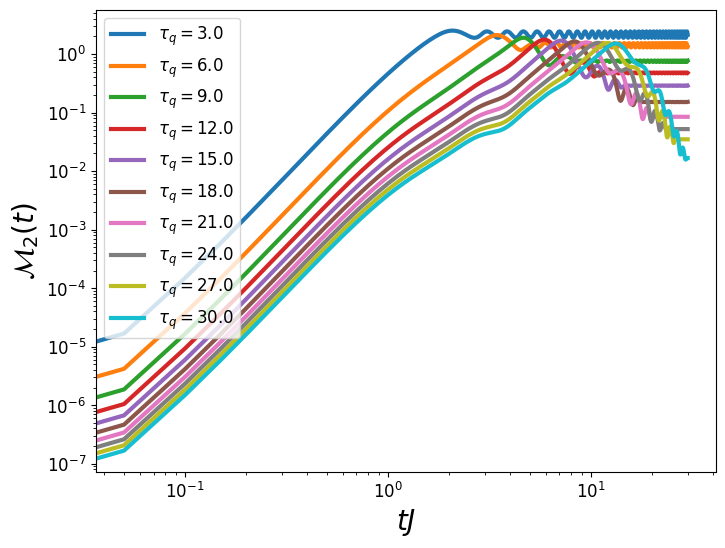

In [ ]:
magic_list = data["magic_list"]
magic_gs_level_list = data["magic_gs_level_list"]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(len(magic_list)):
    plt.plot(
        time,
        magic_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
# plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2 (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

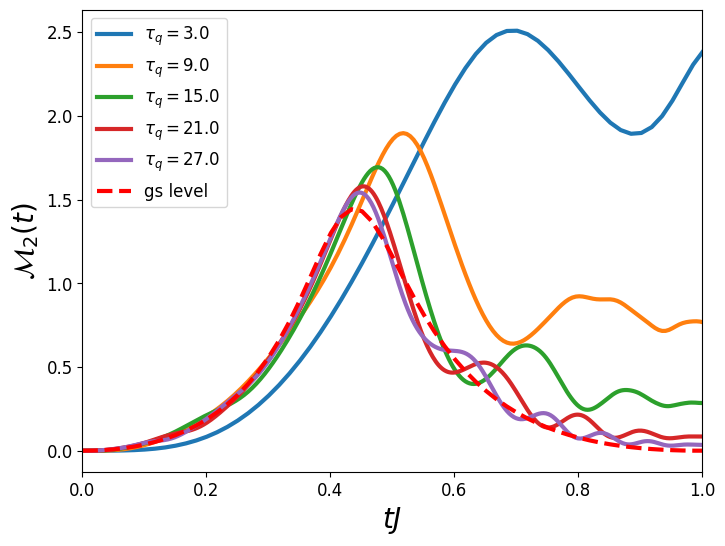

In [ ]:
magic_list = data["magic_list"]
magic_gs_level_list = data["magic_gs_level_list"]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(magic_list), 2):
    plt.plot(
        time / tau_qs[i],
        magic_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
plt.plot(
    time / tau_qs[0],
    magic_gs_level_list[0],
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)
plt.xlim(0, 1)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2 (t)$", fontsize=20)
plt.legend(fontsize=12)

plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

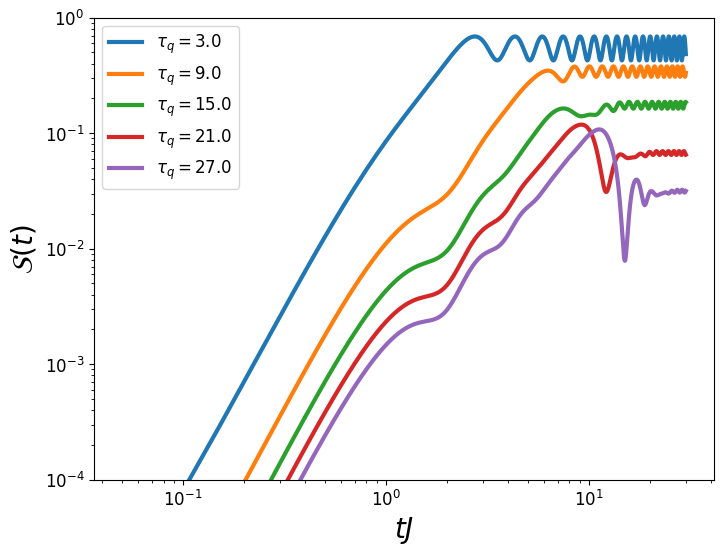

In [ ]:
entanglement_entropy_history_list = data["entanglement_entropy_history_quench_list"]
entanglement_entropy_gs_level_history = data[
    "entanglement_entropy_gs_level_history_list"
]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(entanglement_entropy_history_list), 2):
    plt.plot(
        time,
        entanglement_entropy_history_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
# plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S} (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis="both", which="major", labelsize=12)
plt.ylim(10**-4, 10**0)
plt.show()

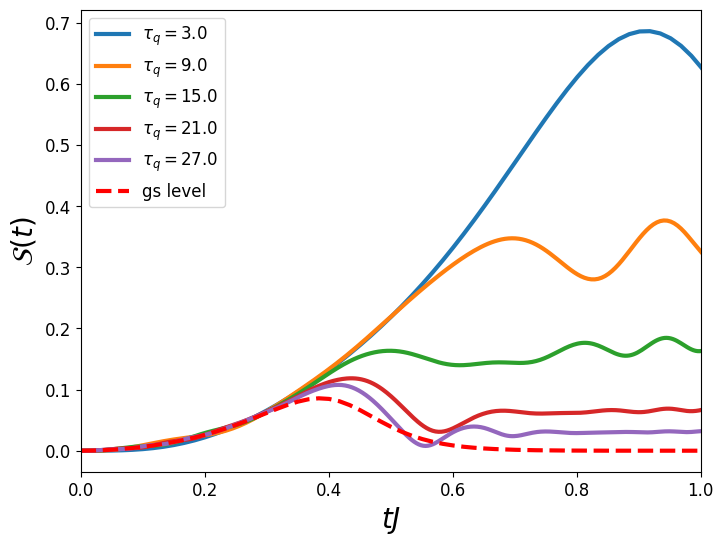

In [ ]:
entanglement_entropy_gs_level_history = data[
    "entanglement_entropy_gs_level_history_list"
]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(entanglement_entropy_history_list), 2):
    plt.plot(
        time / tau_qs[i],
        entanglement_entropy_history_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
plt.plot(
    time / tau_qs[0],
    entanglement_entropy_gs_level_history[0],
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)
plt.xlim(0, 1)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S} (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()